# 03 - Classical baseline: physical features + SVM

A classifier built from interpretable micro-Doppler descriptors. Each
spectrogram column is treated as an energy distribution over velocity; we
summarize the Doppler centroid and bandwidth trajectories, the torso/limb and
positive/negative Doppler energy split, and the temporal envelope
(`radar_pipeline.extract_features`, 26 features). Evaluation is
subject-independent (GroupKFold on the (dataset, subject) key).

The evaluation is staged across notebooks. This notebook and notebook 04 use
dataset 1 alone (360 files, single site, all six classes) for a controlled model
comparison; the multi-site transfer study in notebook 05 drops to five classes
because the care sites barely recorded falls (3 in ds6, none in ds7). So the
project reports a single-site six-class result here and a multi-site five-class
generalization result in notebook 05, not a multi-site six-class one.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import joblib
import radar_pipeline as rp
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GroupKFold
from sklearn.base import clone
from sklearn.metrics import confusion_matrix, accuracy_score

X, meta = rp.load_cache([1])           # dataset 1: balanced, single site
y = meta["activity"] - 1
groups = meta["group"]
F = rp.feature_matrix(X)
print(f"images {X.shape}, features {F.shape}, subjects {len(set(groups))}")
print("feature names:", rp.FEATURE_NAMES)

images (360, 128, 128), features (360, 26), subjects 20
feature names: ['centroid_mean', 'centroid_std', 'centroid_p10', 'centroid_p90', 'centroid_min', 'centroid_max', 'bandwidth_mean', 'bandwidth_std', 'bandwidth_p10', 'bandwidth_p90', 'bandwidth_min', 'bandwidth_max', 'envelope_mean', 'envelope_std', 'envelope_p10', 'envelope_p90', 'envelope_min', 'envelope_max', 'torso_frac', 'limb_frac', 'pos_frac', 'neg_frac', 'peak_abs_centroid', 'peak_bandwidth', 'centroid_swing', 'active_frac']


## Subject-independent cross-validation

In [2]:
models = {
    "SVM (RBF)": make_pipeline(StandardScaler(),
                               SVC(C=10, gamma="scale", random_state=0)),
    "RandomForest": RandomForestClassifier(n_estimators=400, random_state=0,
                                           n_jobs=-1),
}
gkf = GroupKFold(n_splits=5)
results = {}
for name, mk in models.items():
    accs, yt, yp = [], [], []
    for tr, te in gkf.split(F, y, groups):
        m = clone(mk).fit(F[tr], y[tr])
        pred = m.predict(F[te])
        accs.append(accuracy_score(y[te], pred)); yt.append(y[te]); yp.append(pred)
    results[name] = (np.array(accs), np.concatenate(yt), np.concatenate(yp))
    print(f"{name:14s} acc = {np.mean(accs):.3f} +- {np.std(accs):.3f}")

SVM (RBF)      acc = 0.961 +- 0.014


RandomForest   acc = 0.939 +- 0.038


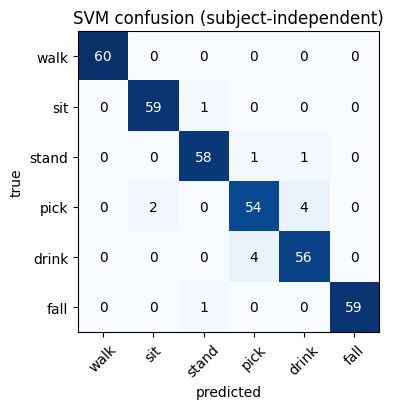

In [3]:
yt, yp = results["SVM (RBF)"][1], results["SVM (RBF)"][2]
cm = confusion_matrix(yt, yp)
names = [rp.ACTIVITY_NAMES[i + 1] for i in range(6)]
fig, ax = plt.subplots(figsize=(5, 4.2))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(6), names, rotation=45); ax.set_yticks(range(6), names)
for i in range(6):
    for j in range(6):
        ax.text(j, i, cm[i, j], ha="center", va="center",
                color="white" if cm[i, j] > cm.max() / 2 else "black")
ax.set(xlabel="predicted", ylabel="true", title="SVM confusion (subject-independent)")
plt.tight_layout(); plt.show()

## What the features see

RandomForest importances show which descriptors carry the signal, which makes the
model defensible rather than a black box.

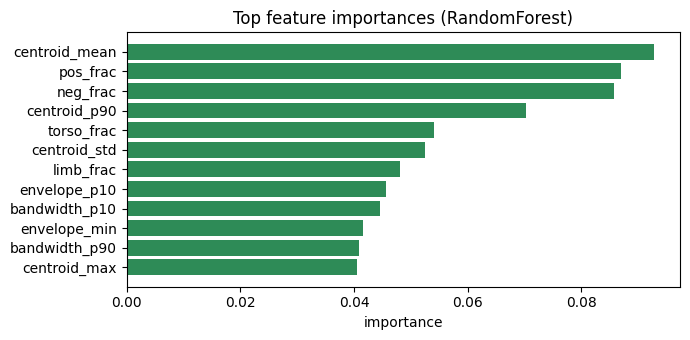

In [4]:
rf = clone(models["RandomForest"]).fit(F, y)
imp = rf.feature_importances_
order = np.argsort(imp)[::-1][:12]
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.barh([rp.FEATURE_NAMES[i] for i in order][::-1], imp[order][::-1],
        color="seagreen")
ax.set(title="Top feature importances (RandomForest)", xlabel="importance")
plt.tight_layout(); plt.show()

## Reading the result

- SVM reaches ~0.96 subject-independent on this clean, balanced single-site data.
- Walking is essentially perfect (sustained periodic signature). The dominant
  error is **pick vs drink**: both are low-velocity arm/torso motions with similar
  Doppler extent. The sit/stand pair, near mirror images in Doppler, is largely
  resolved because the positive/negative-Doppler features capture the Doppler-sign
  asymmetry of the two transients.
- Per class (confusion matrix above, 60 files each): walk 60/60, fall 59/60, sit
  59/60, stand 58/60, drink 56/60. The weakest class is pick at 54/60 (0.90), with
  four of its six misses going to drink.
- For context, published work on this dataset reports about 0.93 with multi-domain
  features and an SVM, so 0.96 on this cleaner single-site, age-homogeneous subset
  is plausible rather than suspicious; the multi-site numbers in notebook 05 are
  the more representative generalization measure.

The final model is refit on all of dataset 1 and saved.

In [5]:
final_svm = clone(models["SVM (RBF)"]).fit(F, y)
joblib.dump(final_svm, "../models/svm_ds1.joblib")
print("saved ../models/svm_ds1.joblib")

saved ../models/svm_ds1.joblib
